# Семинар по бинарной линейной классификации

## Теоретическая часть

### Предсказания в бинарной линейной классификации
__Вспомнить из лекции:__
* Как выполняются предсказания в бинарной линейной классификации?
* Как интерпретировать веса?
* Вспомните обозначения $\langle \cdot, \cdot \rangle$, $sign(z)$, $[z>a]$.

#### Задача 1.
Какое предсказание вернет бинарный линейный классификатор $a(x) = sign(\langle w, x \rangle+w_0)$ для объекта $x=(1, 0, 0, 1, 1)$ при использовании весов $w=(0.1, -0.2, 0.5, -1.1, 0)$ и $w_0=0.35$?

__Решение.__
Запишем скалярное произведение: $\langle w, x \rangle = w_1 x_1 + \dots + w_d x_d$, где $d$ - размерность обоих векторов (число признаков). В нашей задаче $d=5$. Итак, в скобках получится значение $0.1\cdot1 - 0.2\cdot0 + 0.5\cdot 0 -1.1 \cdot 1 + 0 \cdot 1 + 0.35 = -0.65$. Его знак отрицательный, значит $a(x) = -1$.

#### Задача 2.
Визуализируйте разделящую поверхность классификатора $a(x) = sign(\langle w, x \rangle+w_0)$ для $w=(-1, 2)$, $w_0=0.5$, задача бинарной классификации с двумя признаками.

__Решение.__

Предсказания в линейной классификации выполняются по формуле $a(x) = sign(\langle w, x\rangle +w_0)$, то есть класс +1, если выражение в скобках больше 0, и -1, если выражение в скобках меньше 0. Если выражение в скобках равно 0, считаем, что отказываемся от классификации или выбираем случайный класс (на практике такая ситуация встречается очень редко). Соответственно, мы можем сделать такое предсказание в каждой точке признакового пространства, то есть для любого возможного объекта, и получить области классов +1 и -1. Разделяющей границей этих двух областей будет прямая, поэтому классификация линейная.

Разберемся, почему разделяющей границей будет прямая. Вспомним, что уравнение $w_1 x_1 + w_2 x_2 + w_0 = 0$ задает прямую на плоскости в координатах $x_1-x_2$ (мы обычно обозначаем эти координаты $d_1-d_2$, чтобы не путать $x_1$ - первый признак или первый объект в выборке; в данном контексте - первый признак). Все точки $x=(x_1, x_2)$, для которых $w_1 x_1 + w_2 x_2 + w_0 > 0$, находятся с одной стороны от прямой, а все точки, для которых $w_1 x_1 + w_2 x_2 + w_0 < 0$, с другой стороны от прямой. А эти два условия как раз и проверяются в бинарном линейной классификаторе.

В нашем случае прямая задается уравнением $-x_1 + 2 x_2 + 0.5 = 0$. Построим ее по точкам: при $x_1=0$ выполнено $2 x_2+0.5=0$, то есть $x_2=-1/4$; при $x_1=1$ выполнено $2 x_2 -0.5=0$, то есть $x_2=1/4$. Проводим прямую через точки $(0, -1/4)$ и $(1, 1/4)$. Теперь выбираем любую точку, не принадлежащую прямой, например $(0, 1/4)$. Проверяем, какой будет знак выражения $-x_1 + 2 x_2 + 0.5$: $0 + 0.5 + 0.5 = 1 > 0$. Значит, в полуплоскости, где находится эта точка, мы предсказываем класс +1, а в другой - класс -1.

### Вспомнить из лекции
* Какие метрики бинарной классификации вы знаете?
* Какие проблемы есть у метрики accuracy? в каких случаях она нам не подходит?
* Что такое матрица ошибок?

## Практическая часть
В практической части мы обучим линейный классификатор на данных кредитного скорринга, проанализируем веса модели, научимся работать с категориальными признаками в линейных моделях. Далее поработаем с метриками, сравних их между собой и найдем оптимиальные гиперпараметры в модели.

In [3]:
import pandas as pd

Мы будем работать с [данными клиентов банка](https://archive.ics.uci.edu/ml/datasets/statlog+(german+credit+data) (задача кредитного скоринга). Для целей семинара данные были преобразованы в немного другой формат.

Значение признаков:
* account: банковский счет (-1: отриц. баланс, 0: нет счета, 1: до 200 ед., 2: более 200 ед.)
* duration: на какой период запрашивают кредит
* credit_history: рейтинг по кредитной истории (от 0 - отличная кр. история до 4 - критическая ситуация с кредитами)
* amount: на какую сумму запрашивают кредит
* savings: сберегательный счет (0: нет, 1: < 100, 2: 100 <= ... < 500, 3: 500 <= ... < 1000, 4:  >= 1000)
* employment: срок работы на текущей позиции (0: не работает, 1: до 1 года, 2: от 1 до 4 лет, 3: от 4 до 7 лет, 4: более 7 лет)
* guarantors: 1 - есть поручители, 0 - нет
* residence:  сколько лет резидент
* age: возраст, деленный на 100
* credits_number: число кредитов
* job: 0: не работает, 1: неквалифицированный, 2: квалифицированный специалист, 3: высокая должность или бизнес
* maintenance_people: число людей, которых обеспечивает заемщик
* telephone: указан ли телефон (1: да, 0: нет)
* foreign: 1: иностранец, 0: нет
* real_estate: 1: есть недвижимость, 0: нет недвижимости
* life_insurance: 1: оформлено страхование жизни, 0, нет страховки
* car: 1: есть автомобиль, 0: нет автомобиля
* housing_rent: 1: платит за съем жилья, 0: не платит за съем жилья
* sex: пол - 1: муж., 0: жен.
* purpose: на какую цель запрашивают кредит (из нескольких вариантов)
* target: 1: кредит выдан, 0: в кредите отказано

Требуется решить задачу предсказания значения в последнем столбце, то есть задачу бинарной классификации.

По описанию данных понятно, что все признаки числовые (включая вещественные, порядковые, бинарные), кроме предпоследнего, который является категориальным.

In [4]:
import ssl

ssl._create_default_https_context = ssl._create_unverified_context

In [7]:
tab = pd.read_excel("https://github.com/nadiinchi/voronovo_seminar_materials/blob/master/base_track/seminars/scoring.xls?raw=true")

In [8]:
type(tab)

pandas.core.frame.DataFrame

In [9]:
tab.head() # вывести первые строки

,account,duration,credit_history,amount,savings,employment,guarantors,residence,age,credits_number,...,maintenance_people,telephone,foreign,real_estate,life_insurance,car,housing_rent,sex,purpose,target
0,1,0.18,2,0.13110,2,2,1,4,0.34,1,...,1,0,1,0,0,1,0,1,business,1
1,-1,0.18,0,0.15520,1,3,1,1,0.31,1,...,1,1,1,0,1,0,0,1,business,1
2,-1,0.12,2,0.04510,1,3,1,4,0.21,1,...,1,0,1,0,1,0,1,1,retraining,0
3,-1,0.30,0,0.40360,0,1,1,3,0.25,3,...,1,0,1,0,0,1,0,1,business,1
4,0,0.36,2,0.09095,1,2,1,4,0.37,1,...,1,1,1,0,0,0,0,1,education,0


По строкам - объекты (клиенты), по столбцам - признаки, последний столбец - целевая переменная (1 - кредит выдан, 0 - в кредите отказано).

In [10]:
tab.dtypes # типы столбцов

account                 int64
duration              float64
credit_history          int64
amount                float64
savings                 int64
employment              int64
guarantors              int64
residence               int64
age                   float64
credits_number          int64
job                     int64
maintenance_people      int64
telephone               int64
foreign                 int64
real_estate             int64
life_insurance          int64
car                     int64
housing_rent            int64
sex                     int64
purpose                object
target                  int64
dtype: object

Признаки в основном числовые.

In [11]:
tab["target"].value_counts()

target
1    300
0    300
Name: count, dtype: int64

Классы сбалансированы.

Создаем матрицу объекты-признаки и матрицу ответов. Удалим пока столбец с категориальной переменной, чтобы оставить только числовые признаки.

In [12]:
X = tab[tab.columns[:-2]]
y = tab["target"]

In [13]:
X.head()

,account,duration,credit_history,amount,savings,employment,guarantors,residence,age,credits_number,job,maintenance_people,telephone,foreign,real_estate,life_insurance,car,housing_rent,sex
0,1,0.18,2,0.13110,2,2,1,4,0.34,1,2,1,0,1,0,0,1,0,1
1,-1,0.18,0,0.15520,1,3,1,1,0.31,1,2,1,1,1,0,1,0,0,1
2,-1,0.12,2,0.04510,1,3,1,4,0.21,1,2,1,0,1,0,1,0,1,1
3,-1,0.30,0,0.40360,0,1,1,3,0.25,3,2,1,0,1,0,0,1,0,1
4,0,0.36,2,0.09095,1,2,1,4,0.37,1,2,1,1,1,0,0,0,0,1


In [14]:
X.shape, y.shape # атрибут shape показывает размерности матрицы

((600, 19), (600,))

#### Разделение выборки

In [15]:
from sklearn.model_selection import train_test_split
# функция для разделения выборки на обучающую и тестовую

In [16]:
# stratify=y
X_train, X_test, y_train, y_test  = train_test_split(X, y, 
                                                     test_size=0.3,
                                                     shuffle=True,
                                                     random_state=0) #размер выборки теста, перемешивать ли объекты
                                                     # stratify=y

In [17]:
y_train.value_counts()

target
1    222
0    198
Name: count, dtype: int64

In [18]:
y_test.value_counts()

target
0    102
1     78
Name: count, dtype: int64

In [19]:
X_train.shape, y_train.shape

((420, 19), (420,))

#### Нормируем данные

In [20]:
from sklearn.preprocessing import StandardScaler 
# класс scaling, его instance будет выучивать среднее 
# и дисперсию данных

In [21]:
scaler = StandardScaler() # создали instance
X_train = scaler.fit_transform(X_train) 
# он запомнил среднее и дисперсию train, и сразу произвел scaling

X_test = scaler.transform(X_test) 
# отскалировали признаки теста по статистикам из трейн

#### Импортируем класс модели

In [22]:
from sklearn.linear_model import LinearRegression

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score # функция оценки качества

In [24]:
clf_lr = LinearRegression().fit(X_train, y_train) 
# инициализировали модель линрег и сразу обучили на трейн

In [25]:
y_pred = clf_lr.predict(X_test) # предсказали ответы для теста

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [27]:
print(f'Accuracy equals {accuracy_score(y_test, y_pred > 0.5)}')
print(f'Precision equals {precision_score(y_test, y_pred > 0.5)}')
print(f'Recall equals {recall_score(y_test, y_pred > 0.5)}')
print(f'Roc Auc equals {roc_auc_score(y_test, y_pred > 0.5)}')

Accuracy equals 0.6388888888888888
Precision equals 0.5585585585585585
Recall equals 0.7948717948717948
Roc Auc equals 0.6572398190045248


#### Важности и веса признаков
Большинство алгоритмов умеют так или иначе оценивать важности признаков. 
В линейной модели в качестве важностей можно рассматривать веса признаков. Они хранятся в атрибуте coef\_ и появляются, конечно, только после вызова процедуры обучения.

In [29]:
clf_lr.coef_ # веса признаков в обученной модели

array([ 0.03344627, -0.0779239 ,  0.08754819, -0.02066605,  0.03067396,
        0.06774134, -0.00975411,  0.00109616,  0.0185817 , -0.04661195,
        0.00099741, -0.00569433,  0.01735849, -0.03505761,  0.06359324,
       -0.0134745 ,  0.06344944, -0.0416773 ,  0.05088774])

__Задание.__ Оформить веса признаков в виде датафрейма: первый столбец - имя признака, второй столбец - вес, и отсортировать датафрейм по увеличению веса.

__Решение:__

In [30]:
list(zip([1, 2, 3], ['a', 'b', 'c']))

[(1, 'a'), (2, 'b'), (3, 'c')]

In [31]:
list(zip(X.columns.values, clf_lr.coef_))

[('account', 0.033446272396527386),
 ('duration', -0.07792389509861161),
 ('credit_history', 0.08754819305198686),
 ('amount', -0.020666045846670488),
 ('savings', 0.030673959208763306),
 ('employment', 0.06774133867634537),
 ('guarantors', -0.009754112230710219),
 ('residence', 0.0010961620624279848),
 ('age', 0.01858170020867668),
 ('credits_number', -0.04661194579172985),
 ('job', 0.0009974083265196967),
 ('maintenance_people', -0.005694326688745907),
 ('telephone', 0.017358487568532074),
 ('foreign', -0.035057607852054334),
 ('real_estate', 0.06359324272897227),
 ('life_insurance', -0.013474495754774692),
 ('car', 0.06344943715702409),
 ('housing_rent', -0.04167730114394378),
 ('sex', 0.050887735470284225)]

In [32]:
a = [2, -4, 1, 3]
print(sorted(a))
print(sorted(a, key=lambda x : x ** 2))

[-4, 1, 2, 3]
[1, 2, 3, -4]


In [33]:
df = pd.DataFrame(list(zip(X.columns.values, clf_lr.coef_)), 
                 columns=['feature_name', 'weight'])
df.sort_values('weight', key=lambda x : abs(x), ascending=False).head()

,feature_name,weight
2,credit_history,0.087548
1,duration,-0.077924
5,employment,0.067741
14,real_estate,0.063593
16,car,0.063449


Признаки отсортировались по логичным критериям: плата за съем жилья, число кредитов, заемщик-иностранец уменьшают шанс получить кредит; наличие собственности, машины, работы, счета в банке - увеличивают шансы.

Впрочем, некоторые признаки отсортировались менее логично: например, наличие поручителя тоже голосует в "минус", хотя и с маленьким весом.

__Обратите внимание:__ интерпретировать величину весов можно, только если данные отнормированы. Иначе модуль веса будет зависеть от масштаба признака.

#### Работа с категориальным признаком

Применим метод one-hot-encoding к переменной "цель получения кредита", чобы включить ее в модель. Для этого воспользуемся функцией pd.get_dummies

In [34]:
tab_ohe = pd.get_dummies(tab, "purpose", drop_first=True) 
# OHE кодировка категориального признака

In [35]:
tab_ohe.head()

,account,duration,credit_history,amount,savings,employment,guarantors,residence,age,credits_number,...,target,purpose_car_new,purpose_car_used,purpose_domestic_appliances,purpose_education,purpose_furniture,purpose_others,purpose_repairs,purpose_retraining,purpose_television
0,1,0.18,2,0.13110,2,2,1,4,0.34,1,...,1,False,False,False,False,False,False,False,False,False
1,-1,0.18,0,0.15520,1,3,1,1,0.31,1,...,1,False,False,False,False,False,False,False,False,False
2,-1,0.12,2,0.04510,1,3,1,4,0.21,1,...,0,False,False,False,False,False,False,False,True,False
3,-1,0.30,0,0.40360,0,1,1,3,0.25,3,...,1,False,False,False,False,False,False,False,False,False
4,0,0.36,2,0.09095,1,2,1,4,0.37,1,...,0,False,False,False,True,False,False,False,False,False


In [36]:
# удаляем целевую переменную с помощью метода drop
X_ohe = tab_ohe.drop("target", axis=1)
# axis=1 показывает, что мы отим удалить столбец, а не строку (axis=0)

In [37]:
X_train_ohe, X_test_ohe, y_train, y_test  = train_test_split(X_ohe, y, \
                                                     test_size=0.3,\
                                                     shuffle=True,
                                                     random_state=0)

In [38]:
scaler = StandardScaler()
X_train_ohe = scaler.fit_transform(X_train_ohe)
X_test_ohe = scaler.transform(X_test_ohe)

Благодаря фиксации random_state=0 мы получаем одно и то же разделение.

Оформим обучение классификатора и подсчет качества в виде функции:

In [39]:
def get_accuracy(clf): # instance модели на вход
    clf.fit(X_train_ohe, y_train) # обучили модель
    y_pred = clf.predict(X_test_ohe) # прогнозируем
    return accuracy_score(y_test, y_pred > 0.5) # возвращаем метрику качества

In [40]:
print(get_accuracy(LinearRegression()))

0.6666666666666666


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


Качество с новым признаком повысилось.

А что, если мы просто пронумеруем категории? Для этого воспользуемся классом LabelEncoder:

In [41]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [42]:
tab["purpose"] = LabelEncoder().fit_transform(tab["purpose"])

In [43]:
X_le = tab[tab.columns[:-1]] # удаляем таргеты

In [44]:
X_train_le, X_test_le, y_train, y_test  = train_test_split(X_le, y, \
                                                     test_size=0.3,\
                                                     shuffle=True,
                                                     random_state=0)

In [45]:
scaler = StandardScaler()
X_train_le = scaler.fit_transform(X_train_le)
X_test_le = scaler.transform(X_test_le)

In [46]:
print(get_accuracy(LinearRegression()))

0.6666666666666666


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [47]:
from sklearn.pipeline import Pipeline

X_train_le, X_test_le, y_train, y_test  = train_test_split(X_le, y, \
                                                     test_size=0.3,\
                                                     shuffle=True,
                                                     random_state=0)

pipe = Pipeline(steps=[
    ('scale', StandardScaler()),
    ('model', LinearRegression())
])

pipe.fit(X_train_le, y_train)
y_pred = pipe.predict(X_test_le)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


Посчитаем метрики нашей модели. Метрики разобранные на лекции уже реализованы в библиотеке scikit-learn.

In [48]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix, f1_score

In [49]:
confusion_matrix(y_test, y_pred > 0.5)

array([[55, 47],
       [16, 62]])

In [50]:
accuracy_score(y_test, y_pred > 0.5)

0.65

In [51]:
precision_score(y_test, y_pred > 0.5)

0.5688073394495413

In [52]:
recall_score(y_test, y_pred > 0.5)

0.7948717948717948

In [53]:
f1_score(y_test, y_pred > 0.5)

0.6631016042780749

Порог 0.5 мы выбрали самостоятельно, и мы можем его менять. Как увелечиение порога отразится на precision/recall?

На практике, перед нами всегда встает трейдофф - потерять часть сигнала взамен на большую точность или получить false positives взамен на больший recall.

Постройте на одном графике precision, recall и f1 score в зависимости от порога.

In [54]:
import numpy as np
from tqdm.notebook import tqdm

prec, rec, f1 = [], [], []

for threshold in tqdm(np.linspace(0, 1, 1000)):
    prec.append(precision_score(y_test, y_pred > threshold))
    rec.append(recall_score(y_test, y_pred > threshold))
    f1.append(f1_score(y_test, y_pred > threshold))

  0%|          | 0/1000 [00:00<?, ?it/s]

In [58]:
# 10-5 10-1
np.linspace(0.00001, 0.1, 10)
#np.linspace(0, 1, 10)

array([1.000e-05, 1.112e-02, 2.223e-02, 3.334e-02, 4.445e-02, 5.556e-02,
       6.667e-02, 7.778e-02, 8.889e-02, 1.000e-01])

In [59]:
np.logspace(-5, -1, 10)

array([1.00000000e-05, 2.78255940e-05, 7.74263683e-05, 2.15443469e-04,
       5.99484250e-04, 1.66810054e-03, 4.64158883e-03, 1.29154967e-02,
       3.59381366e-02, 1.00000000e-01])

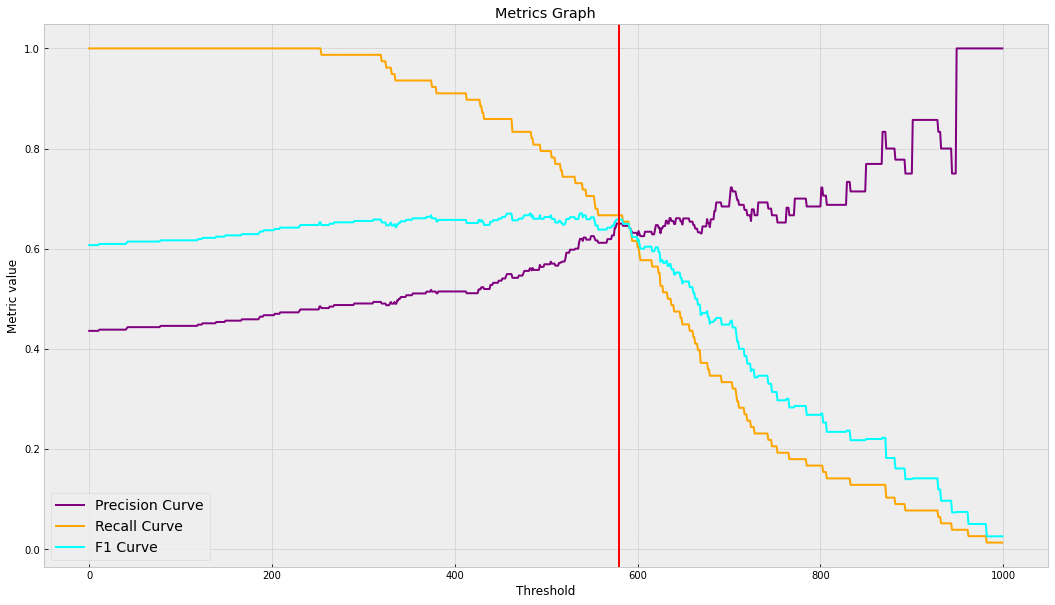

In [60]:
import matplotlib.pyplot as plt

plt.style.use('bmh')
fig = plt.figure(figsize=(18, 10))
plt.plot(prec, label='Precision Curve', color='purple')
plt.plot(rec, label='Recall Curve', color='orange')
plt.plot(f1, label='F1 Curve', color='cyan')
plt.legend(prop={'size': 14})
plt.grid(True)
plt.title('Metrics Graph')
plt.xlabel('Threshold')
plt.ylabel('Metric value')
plt.axvline(x=580, color='red')
plt.show()

In [62]:
np.linspace(0, 1, 1000)[580]

0.5805805805805806

Какой порог соответствует максимизации f1 score?

Обучите линейную регрессию с регуляризацией и подберите параметр регуляризации исходя из максимального f1-score.

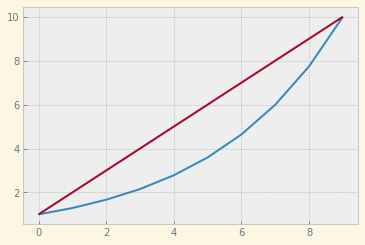

In [148]:
plt.plot(np.logspace(0, 1, 10))
plt.plot(np.linspace(1, 10, 10))

In [63]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso

parameters = {'alpha' : np.logspace(-5, 0, 100)}

cv = GridSearchCV(Lasso(), parameters, cv=10)
cv.fit(X_train_ohe, y_train)

GridSearchCV(cv=10, estimator=Lasso(),
             param_grid={'alpha': array([1.00000000e-05, 1.12332403e-05, 1.26185688e-05, 1.41747416e-05,
       1.59228279e-05, 1.78864953e-05, 2.00923300e-05, 2.25701972e-05,
       2.53536449e-05, 2.84803587e-05, 3.19926714e-05, 3.59381366e-05,
       4.03701726e-05, 4.53487851e-05, 5.09413801e-05, 5.72236766e-05,
       6.42807312e-05, 7.22080902e-05, 8.11130831e-05, 9...
       6.89261210e-02, 7.74263683e-02, 8.69749003e-02, 9.77009957e-02,
       1.09749877e-01, 1.23284674e-01, 1.38488637e-01, 1.55567614e-01,
       1.74752840e-01, 1.96304065e-01, 2.20513074e-01, 2.47707636e-01,
       2.78255940e-01, 3.12571585e-01, 3.51119173e-01, 3.94420606e-01,
       4.43062146e-01, 4.97702356e-01, 5.59081018e-01, 6.28029144e-01,
       7.05480231e-01, 7.92482898e-01, 8.90215085e-01, 1.00000000e+00])})

In [64]:
cv.best_estimator_

Lasso(alpha=0.003351602650938841)

### Logistic Regression

In [54]:
from sklearn.linear_model import LogisticRegression, Ridge

In [67]:
precision_score.__name__

'precision_score'

In [69]:
X_train_ohe, X_test_ohe, y_train, y_test  = train_test_split(X_ohe, y, \
                                                     test_size=0.3,\
                                                     shuffle=True,
                                                     random_state=0)

results = {}
for model in [LinearRegression(), LogisticRegression(), Ridge()]:
    results[model.__repr__()] = {}
    pipe = Pipeline(steps=[
        ('scale', StandardScaler()),
        ('model', model)
    ])
    
    pipe.fit(X_train_ohe, y_train)
    y_pred = pipe.predict(X_test_ohe)

    for metric in [precision_score, recall_score, f1_score, accuracy_score, roc_auc_score]:
        results[model.__repr__()][metric.__name__] = metric(y_test, y_pred > 0.5)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw

In [71]:
pd.DataFrame(results)

,LinearRegression(),LogisticRegression(),Ridge()
precision_score,0.584906,0.586538,0.584906
recall_score,0.794872,0.782051,0.794872
f1_score,0.673913,0.670330,0.673913
accuracy_score,0.666667,0.666667,0.666667
roc_auc_score,0.681750,0.680241,0.681750
